# Native positive semidefiniteness

Manuscript Section 6.1. Only **GH08 and Pairwise** are evaluated. Draw **40 station geometries**, each containing **40 distinct stations** in a real event, using all nine periods and seed 123. Each 360 × 360 correlation matrix is tested before generating residuals. Also report the corresponding marginal-variance-scaled covariance matrix.

Choose eligible events uniformly, then sample complete-case station records without replacement within the event. Full-data model parameters stay fixed. There is no refitting, PSD correction, nugget or jitter. `PSD` means the minimum eigenvalue is at least -1e-8. The complete run below is inexpensive and executes every time; no cached PSD summary is read and no files are written.

In [1]:
%matplotlib inline
from pathlib import Path
import sys
from IPython.display import display
from threadpoolctl import threadpool_limits
import matplotlib.pyplot as plt

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'scripts/models').is_dir())
sys.path.insert(0, str(ROOT))
from scripts.analysis.psd.evaluate import evaluate, plot
CACHE = ROOT / 'results/analysis/model_fit/models.pkl'


In [2]:
with threadpool_limits(limits=1):
    results = evaluate(CACHE, stations=40, repeats=40, seed=123)
display(results['summary'])

,model,scale,PSD_count,n,min_eigenvalue_worst,min_eigenvalue_median,min_eigenvalue_best
0,GH08,correlation,0,40,-0.121472,-0.094721,-0.066068
1,GH08,covariance,0,40,-0.158016,-0.123265,-0.085834
2,Pairwise fit,correlation,2,40,-0.743332,-0.101583,0.001891
3,Pairwise fit,covariance,2,40,-0.807518,-0.126990,0.002448


The median minimum eigenvalue summarizes a typical geometry; the worst value is a separate quantity. Correlation and covariance scaling have the same PSD verdict.

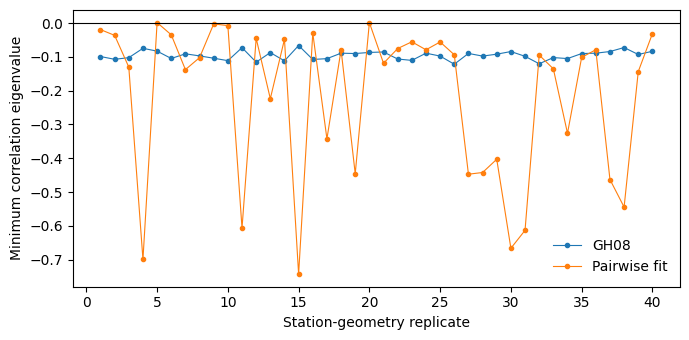

In [3]:
figure = plot(results)
plt.show()

## Inspect the geometry and each result

The sampled station records and all native eigenvalues are returned as DataFrames, so another experiment can reuse exactly these geometries.

In [4]:
display(results['detail'].head(8))
display(results['samples'].head())
print('Unique station locations per replicate:')
display(results['samples'].drop_duplicates(['repeat', 'station_latitude', 'station_longitude']).groupby('repeat').size().value_counts().rename_axis('stations').to_frame('replicates'))

,model,scale,repeat,eqid,min_eigenvalue,PSD
0,GH08,correlation,0,118,-0.098665,False
1,GH08,covariance,0,118,-0.128119,False
2,Pairwise fit,correlation,0,118,-0.018911,False
3,Pairwise fit,covariance,0,118,-0.020210,False
4,GH08,correlation,1,1002,-0.106909,False
5,GH08,covariance,1,1002,-0.138913,False
6,Pairwise fit,correlation,1,1002,-0.036001,False
7,Pairwise fit,covariance,1,1002,-0.046148,False


,repeat,eqid,recid,station_latitude,station_longitude
0,0,118,732,37.657,-122.082
1,0,118,736,37.397,-121.952
2,0,118,737,37.785,-122.303
3,0,118,740,37.047,-121.984
4,0,118,743,36.658,-121.249


Unique station locations per replicate:


,replicates
stations,
40,40
